# SurfCast SD — EDA on Enriched Training Set
**Dataset:** `data/processed/training_set_enriched.csv`  
**Target:** `rating_key` (VERY_POOR → EPIC)  
**Features:** swell (WVHT, DPD, MWD, APD), tide, wind, season (astral), temperature, humidity

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

ROOT    = Path('..')
CSV     = ROOT / 'data/processed/training_set_enriched.csv'

RATING_ORDER = ['VERY_POOR','POOR','POOR_TO_FAIR','FAIR','FAIR_TO_GOOD','GOOD','EPIC']
PALETTE      = ['#d62728','#ff7f0e','#ffbb78','#2ca02c','#98df8a','#1f77b4','#9467bd']

FEATURE_COLS = [
    'WVHT', 'DPD', 'MWD', 'APD',
    'tide_height_m', 'wind_speed_mph', 'wind_direction_deg',
    'day_length_hours', 'hours_since_sunrise', 'season_sin', 'season_cos',
    'temp_c', 'humidity_pct'
]

FEATURE_LABELS = {
    'WVHT':                'Wave Height (m)',
    'DPD':                 'Dominant Period (s)',
    'MWD':                 'Mean Wave Direction (°)',
    'APD':                 'Average Period (s)',
    'tide_height_m':       'Tide Height (m)',
    'wind_speed_mph':      'Wind Speed (mph)',
    'wind_direction_deg':  'Wind Direction (°)',
    'day_length_hours':    'Day Length (hours)',
    'hours_since_sunrise': 'Hours Since Sunrise',
    'season_sin':          'Season Sin (circular)',
    'season_cos':          'Season Cos (circular)',
    'temp_c':              'Temperature (°C)',
    'humidity_pct':        'Relative Humidity (%)'
}

## 1. Load Data

In [2]:
df = pd.read_csv(CSV, parse_dates=['timestamp_utc'])
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

print(f'Shape:      {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["timestamp_utc"].min().date()} → {df["timestamp_utc"].max().date()}')
print(f'Breaks:     {df["break_id"].unique().tolist()}')
print(f'Columns:    {list(df.columns)}')
df.head(3)

Shape:      303,375 rows × 20 columns
Date range: 2022-01-01 → 2024-12-30
Breaks:     ['blacks', 'la_jolla_shores', 'pb_point']
Columns:    ['timestamp_utc', 'station', 'WVHT', 'DPD', 'MWD', 'APD', 'tide_height_m', 'wind_speed_mph', 'wind_direction_deg', 'break_id', 'rating_key', 'rating_value', 'sunrise_hour_utc', 'sunset_hour_utc', 'day_length_hours', 'hours_since_sunrise', 'season_sin', 'season_cos', 'temp_c', 'humidity_pct']


,timestamp_utc,station,WVHT,DPD,MWD,APD,tide_height_m,wind_speed_mph,wind_direction_deg,break_id,rating_key,rating_value,sunrise_hour_utc,sunset_hour_utc,day_length_hours,hours_since_sunrise,season_sin,season_cos,temp_c,humidity_pct
0,2022-01-01 08:26:00+00:00,46232,2.18,9.09,275.0,6.79,0.7449,3.35541,210.0,blacks,POOR,1.0,14.85,0.883333,10.039461,0.0,0.017213,0.999852,16.1,62.350548
1,2022-01-01 08:26:00+00:00,46254,1.35,9.09,282.0,6.26,0.7449,3.35541,210.0,blacks,POOR,1.0,14.85,0.883333,10.039461,0.0,0.017213,0.999852,16.1,62.350548
2,2022-01-01 08:26:00+00:00,46232,2.18,9.09,275.0,6.79,0.7449,3.35541,210.0,la_jolla_shores,POOR_TO_FAIR,2.0,14.85,0.883333,10.039461,0.0,0.017213,0.999852,16.1,62.350548


## 2. Summary Statistics

In [3]:
display(df[FEATURE_COLS].describe().round(2))

,WVHT,DPD,MWD,APD,tide_height_m,wind_speed_mph,wind_direction_deg,day_length_hours,hours_since_sunrise,season_sin,season_cos,temp_c,humidity_pct
count,303306.00,303243.00,303243.00,303306.00,303375.00,303003.00,224751.00,303375.00,303375.00,303375.00,303375.00,303015.00,302955.00
mean,1.04,11.73,260.39,6.96,0.98,5.30,246.53,12.16,2.33,0.01,0.01,17.31,71.39
std,0.50,3.65,37.77,1.71,0.53,3.91,78.81,1.49,3.31,0.70,0.71,4.31,15.38
min,0.22,2.44,150.00,2.90,-0.66,0.00,10.00,9.99,0.00,-1.00,-1.00,3.85,6.96
25%,0.68,8.33,243.00,5.76,0.61,2.35,200.00,10.70,0.00,-0.69,-0.71,14.40,64.49
50%,0.95,12.50,278.00,6.68,1.01,4.92,280.00,12.18,0.00,0.03,0.02,17.20,73.70
75%,1.24,14.29,287.00,7.85,1.34,8.05,300.00,13.61,4.58,0.72,0.71,20.37,82.06
max,4.98,22.22,325.00,15.81,2.47,36.91,360.00,14.30,11.27,1.00,1.00,34.40,100.00


In [4]:
print('Missing values:')
missing = df[FEATURE_COLS].isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else 'None')

Missing values:
WVHT                     69
DPD                     132
MWD                     132
APD                      69
wind_speed_mph          372
wind_direction_deg    78624
temp_c                  360
humidity_pct            420


,count,pct_%
rating_key,,
VERY_POOR,2216,0.7
POOR,22801,7.5
POOR_TO_FAIR,121207,40.0
FAIR,142579,47.0
FAIR_TO_GOOD,13880,4.6
GOOD,668,0.2
EPIC,24,0.0


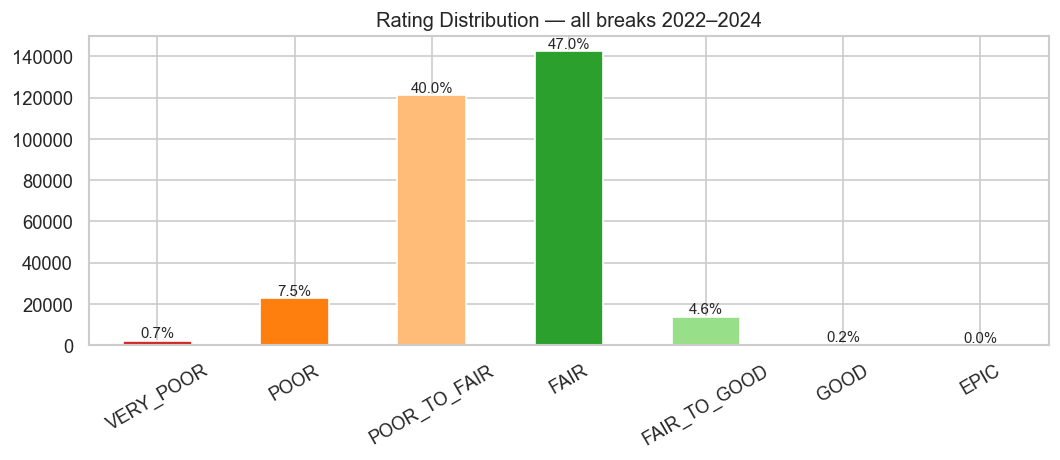

In [5]:
# Target distribution
counts = df['rating_key'].value_counts().reindex(RATING_ORDER).dropna()
pct    = (counts / len(df) * 100).round(1)
display(pd.DataFrame({'count': counts, 'pct_%': pct}))

fig, ax = plt.subplots(figsize=(9, 4))
counts.plot(kind='bar', ax=ax, color=PALETTE, edgecolor='white')
for p in ax.patches:
    ax.annotate(f'{p.get_height()/len(df)*100:.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.set_title('Rating Distribution — all breaks 2022–2024', fontsize=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 3. Each Feature vs Target
**Violin plots** show the full distribution shape per rating class — wider = more data there, inner lines = quartiles.  
Followed by **KDE overlays** for the most diagnostic features to see how much the distributions overlap.

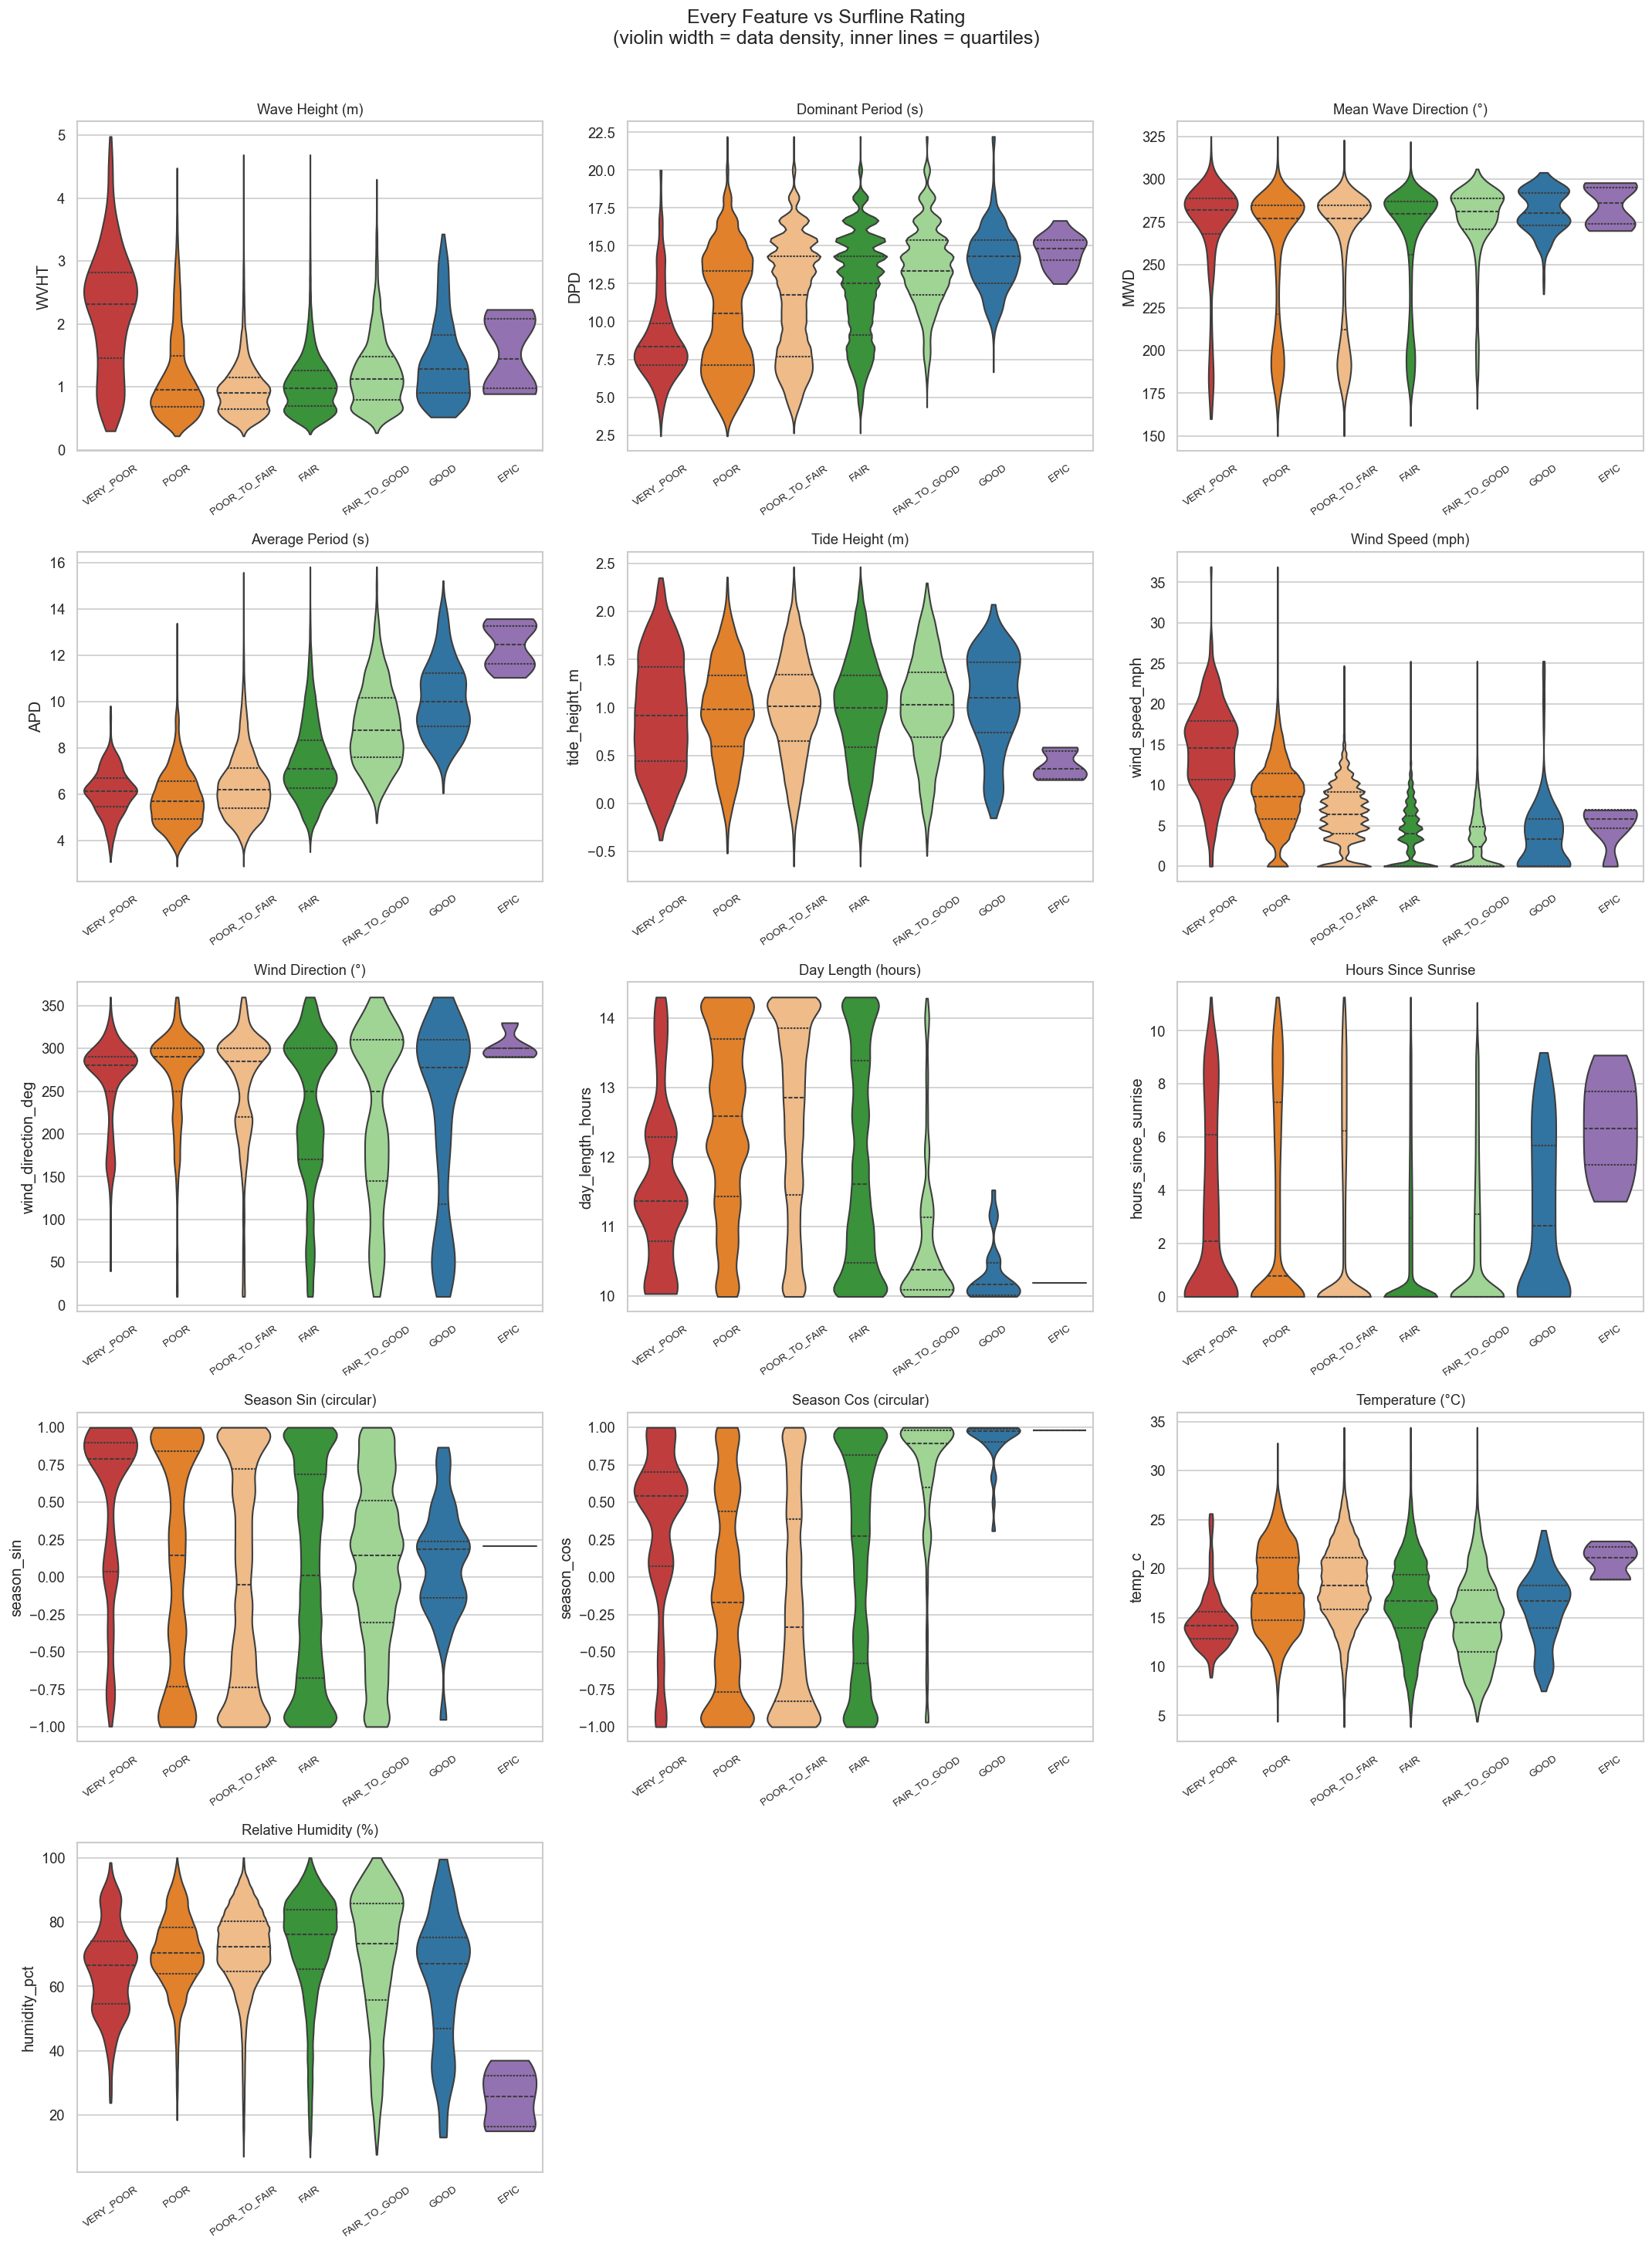

In [6]:
sub = df[df['rating_key'].isin(RATING_ORDER)]

fig, axes = plt.subplots(5, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    sns.violinplot(
        data=sub, x='rating_key', y=col,
        order=RATING_ORDER, palette=PALETTE,
        ax=axes[i], inner='quartile', cut=0
    )
    axes[i].set_title(FEATURE_LABELS[col], fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35, labelsize=8)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Every Feature vs Surfline Rating\n(violin width = data density, inner lines = quartiles)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

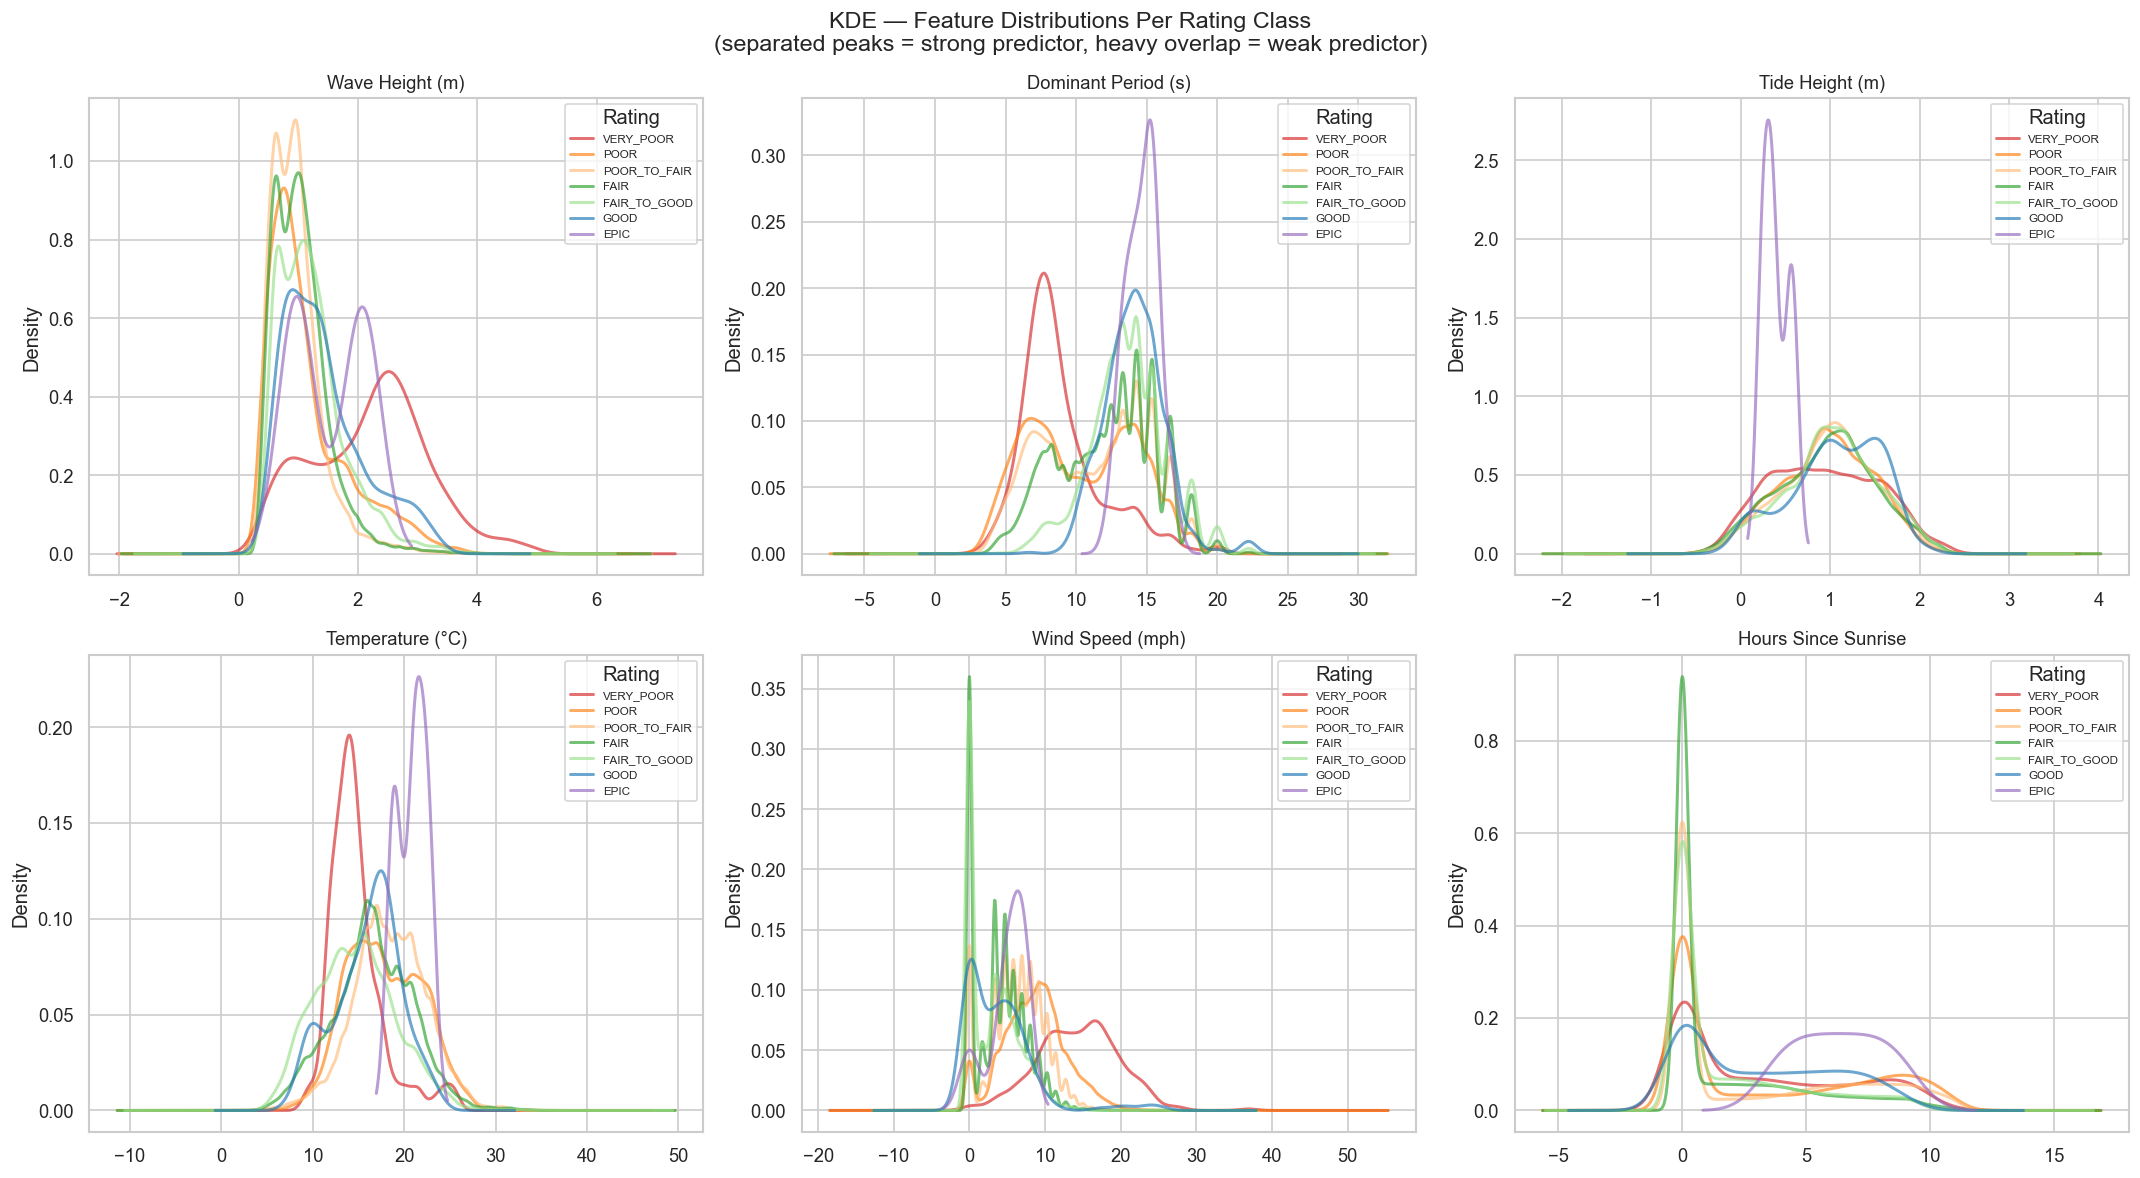

In [7]:
# KDE: full distribution of each feature per rating — shows how much classes overlap
top_features = ['WVHT', 'DPD', 'tide_height_m', 'temp_c', 'wind_speed_mph', 'hours_since_sunrise']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    for rating, color in zip(RATING_ORDER, PALETTE):
        vals = sub[sub['rating_key'] == rating][col].dropna()
        if len(vals) > 10:
            vals.plot.kde(ax=axes[i], label=rating, color=color, alpha=0.65, linewidth=1.8)
    axes[i].set_title(FEATURE_LABELS[col], fontsize=11)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7, title='Rating')

fig.suptitle('KDE — Feature Distributions Per Rating Class\n(separated peaks = strong predictor, heavy overlap = weak predictor)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Season Feature Deep Dive
Season is critical — it controls when dawn happens, which sets how long the offshore morning window lasts before onshore winds kick in. Summer dawn (~5:30am) gives 4+ hours of clean surf; winter dawn (~6:30am) shrinks that window.

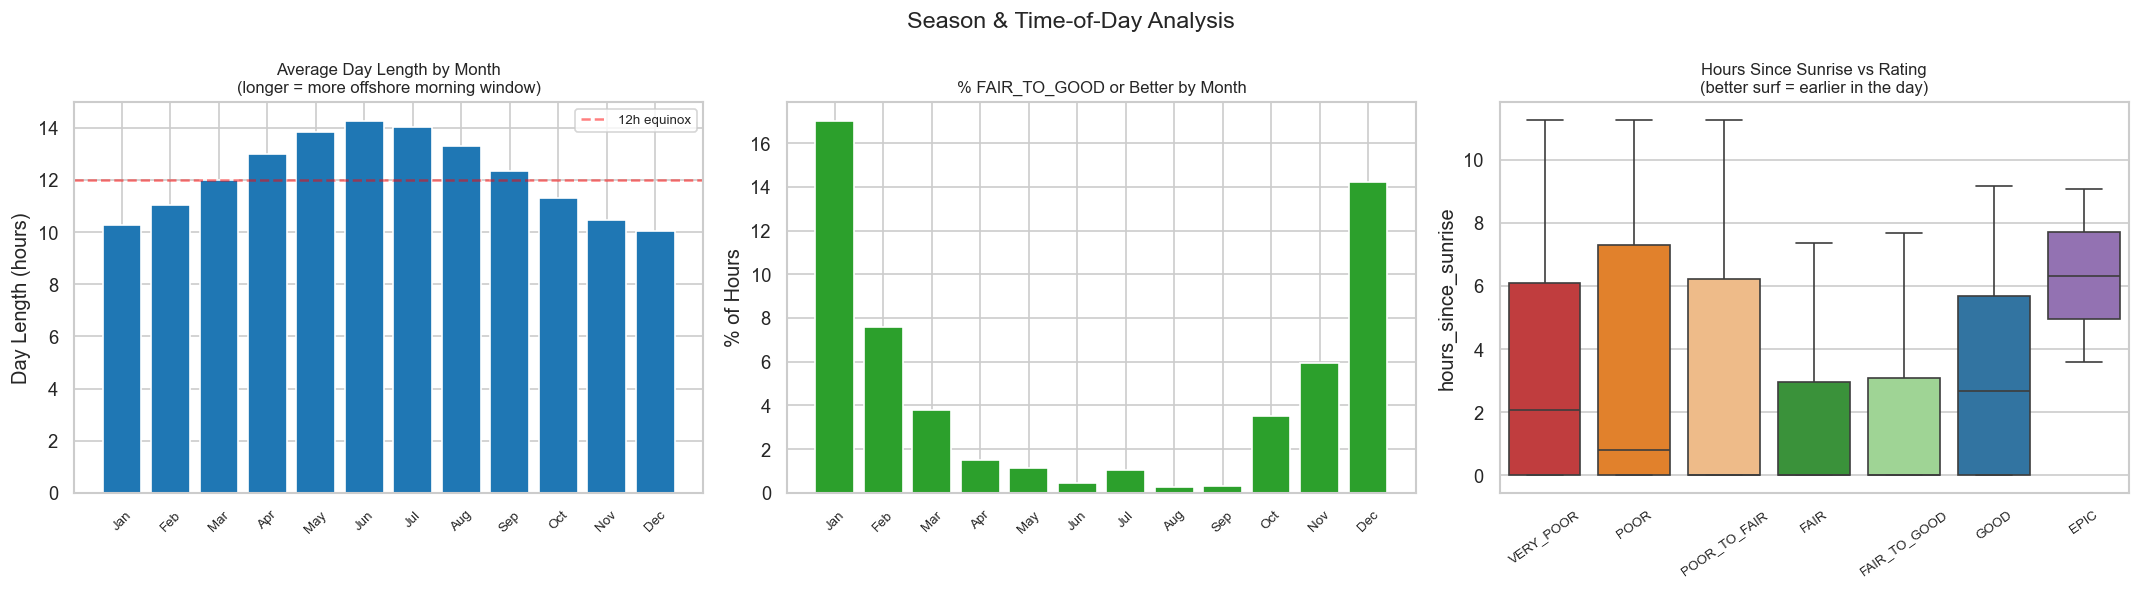

In [8]:
df['month'] = df['timestamp_utc'].dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Day length by month
monthly_daylen = df.groupby('month')['day_length_hours'].mean()
axes[0].bar(range(1,13), monthly_daylen.values, color='#1f77b4')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names, rotation=45, fontsize=8)
axes[0].set_title('Average Day Length by Month\n(longer = more offshore morning window)', fontsize=10)
axes[0].set_ylabel('Day Length (hours)')
axes[0].axhline(12, color='red', linestyle='--', alpha=0.5, label='12h equinox')
axes[0].legend(fontsize=8)

# Good+ ratings by month
good_ratings = ['FAIR_TO_GOOD','GOOD','EPIC']
df['is_good'] = df['rating_key'].isin(good_ratings)
monthly_good = df.groupby('month')['is_good'].mean() * 100
axes[1].bar(range(1,13), monthly_good.values, color='#2ca02c')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names, rotation=45, fontsize=8)
axes[1].set_title('% FAIR_TO_GOOD or Better by Month', fontsize=10)
axes[1].set_ylabel('% of Hours')

# Hours since sunrise vs rating
sns.boxplot(
    data=sub, x='rating_key', y='hours_since_sunrise',
    order=RATING_ORDER, palette=PALETTE,
    ax=axes[2], showfliers=False
)
axes[2].set_title('Hours Since Sunrise vs Rating\n(better surf = earlier in the day)', fontsize=10)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=35, labelsize=8)

plt.suptitle('Season & Time-of-Day Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Dimensionality Reduction & Natural Clustering
**PCA** shows linear structure and which features drive variance.  
**t-SNE** uses a non-linear projection — much better at revealing natural groupings in the data.  
**K-Means** then tests whether the data clusters on its own (no labels used), and we compare those clusters to the actual Surfline ratings using the Adjusted Rand Index.

Running t-SNE (may take ~30s)...


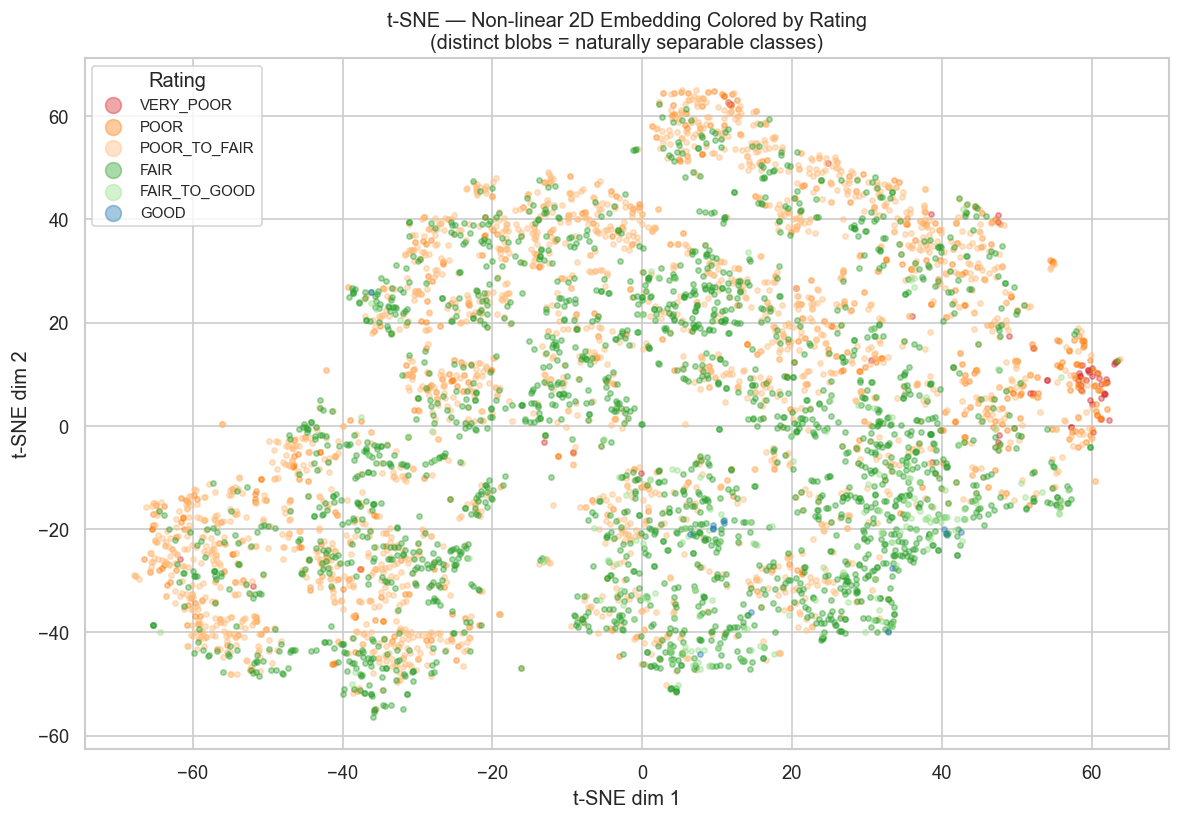


Running K-Means elbow analysis (k=2..8)...


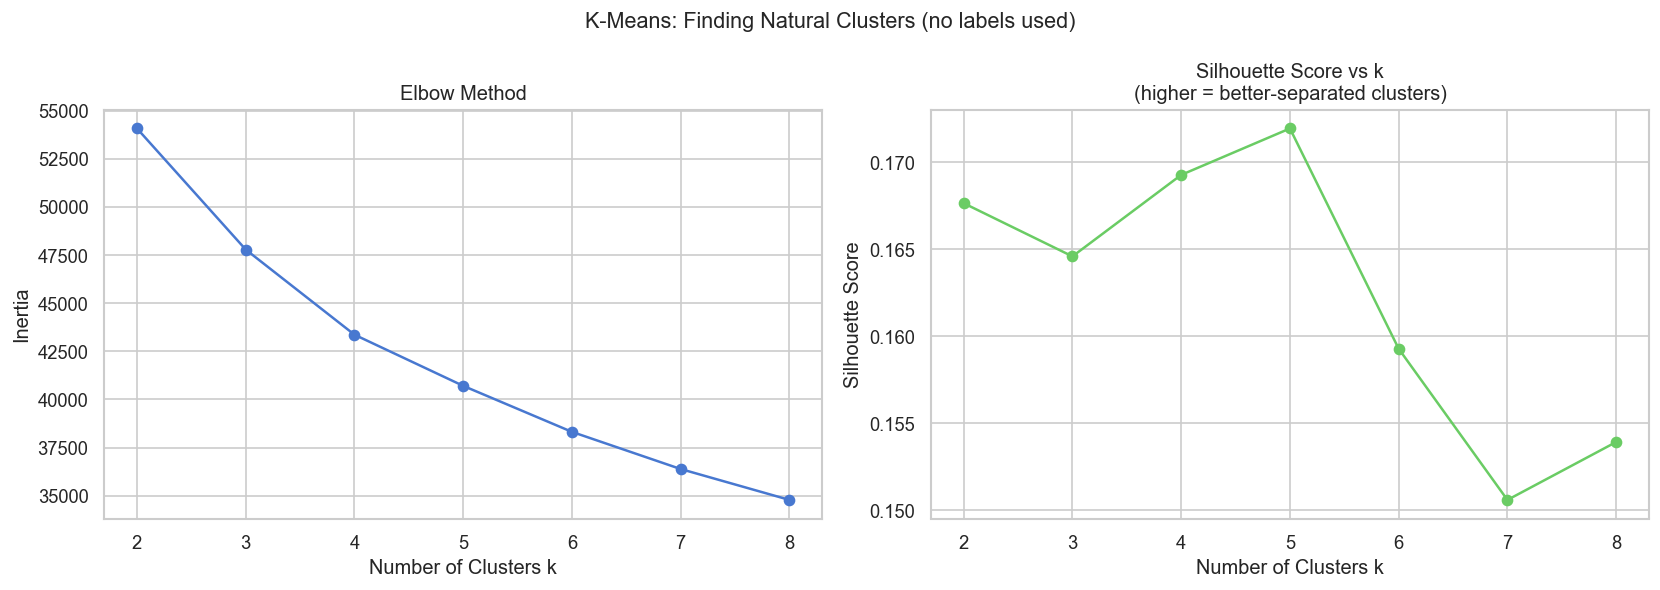


Best k by silhouette = 5
Silhouette Score (k=5): 0.172  (0=random overlap, 1=perfect separation)
Adjusted Rand Index vs Surfline ratings: 0.042  (0=random, 1=perfect match)


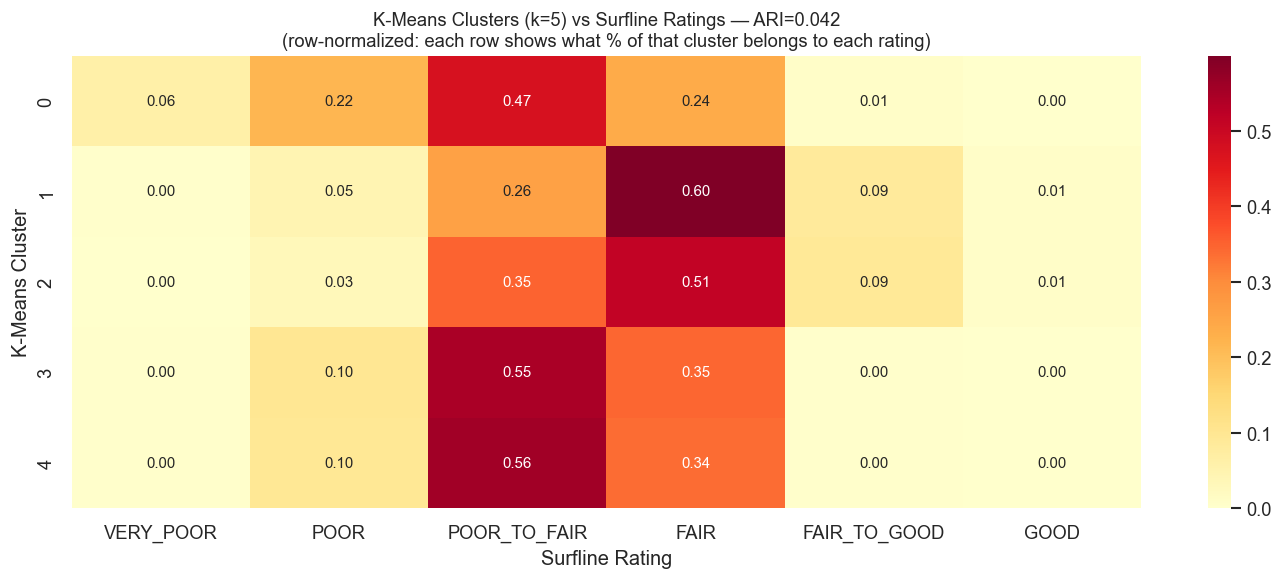

In [9]:
sample = sub.dropna(subset=FEATURE_COLS).sample(n=min(5000, len(sub)), random_state=42)
X_scaled = StandardScaler().fit_transform(sample[FEATURE_COLS])
color_map = dict(zip(RATING_ORDER, PALETTE))

# --- t-SNE ---
print("Running t-SNE (may take ~30s)...")
tsne_coords = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000).fit_transform(X_scaled)

tsne_df = pd.DataFrame({'x': tsne_coords[:,0], 'y': tsne_coords[:,1], 'rating': sample['rating_key'].values})
fig, ax = plt.subplots(figsize=(10, 7))
for rating in RATING_ORDER:
    s = tsne_df[tsne_df['rating'] == rating]
    if len(s):
        ax.scatter(s['x'], s['y'], label=rating, alpha=0.4, s=10, color=color_map[rating])
ax.set_title('t-SNE — Non-linear 2D Embedding Colored by Rating\n(distinct blobs = naturally separable classes)', fontsize=12)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(markerscale=3, fontsize=9, title='Rating')
plt.tight_layout()
plt.show()

# --- K-Means elbow to find natural k ---
print("\nRunning K-Means elbow analysis (k=2..8)...")
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbls, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, 'go-')
axes[1].set_xlabel('Number of Clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k\n(higher = better-separated clusters)')
plt.suptitle('K-Means: Finding Natural Clusters (no labels used)', fontsize=13)
plt.tight_layout()
plt.show()

# --- Best k: compare clusters to actual Surfline labels ---
best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nBest k by silhouette = {best_k}")
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_scaled)

le = LabelEncoder()
true_enc = le.fit_transform(sample['rating_key'].fillna('POOR'))
ari = adjusted_rand_score(true_enc, cluster_labels)
best_sil = sil_scores[best_k - 2]
print(f"Silhouette Score (k={best_k}): {best_sil:.3f}  (0=random overlap, 1=perfect separation)")
print(f"Adjusted Rand Index vs Surfline ratings: {ari:.3f}  (0=random, 1=perfect match)")

ct = pd.crosstab(cluster_labels, sample['rating_key'])
ct = ct.reindex(columns=[r for r in RATING_ORDER if r in ct.columns])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, max(4, best_k)))
sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, annot_kws={'size': 9})
ax.set_title(
    f'K-Means Clusters (k={best_k}) vs Surfline Ratings — ARI={ari:.3f}\n'
    f'(row-normalized: each row shows what % of that cluster belongs to each rating)',
    fontsize=11
)
ax.set_xlabel('Surfline Rating')
ax.set_ylabel('K-Means Cluster')
plt.tight_layout()
plt.show()

## 6. Statistical Feature Importance — ANOVA + Kruskal-Wallis
**ANOVA F-test** (parametric): tests whether feature means differ across rating classes. Assumes normality.  
**Kruskal-Wallis H-test** (non-parametric): same question, no normality assumption — more appropriate for skewed surf data.  
If both agree → strong signal. If they disagree → the distribution is non-normal and K-W is more trustworthy.

In [10]:
results = []
clean = sub.dropna(subset=FEATURE_COLS)

for col in FEATURE_COLS:
    groups = [g[col].values for _, g in clean.groupby('rating_key') if len(g) > 1]
    if len(groups) < 2:
        continue
    f, p_anova   = stats.f_oneway(*groups)
    h, p_kruskal = stats.kruskal(*groups)
    results.append({
        'feature': col, 'label': FEATURE_LABELS[col],
        'F': f, 'p_anova': p_anova,
        'H': h, 'p_kruskal': p_kruskal,
    })

imp = pd.DataFrame(results).sort_values('F', ascending=False).reset_index(drop=True)
imp['sig_anova']   = imp['p_anova']   < 0.05
imp['sig_kruskal'] = imp['p_kruskal'] < 0.05
display(imp[['label','F','p_anova','H','p_kruskal','sig_anova','sig_kruskal']].round(4))

,label,F,p_anova,H,p_kruskal,sig_anova,sig_kruskal
0,Average Period (s),7984.2581,0.0,37991.4215,0.0,True,True
1,Wind Speed (mph),7930.9200,0.0,30608.1467,0.0,True,True
2,Season Cos (circular),3148.1481,0.0,16734.0512,0.0,True,True
3,Day Length (hours),2928.4219,0.0,15275.0419,0.0,True,True
4,Wave Height (m),2812.3793,0.0,5994.1608,0.0,True,True
5,Wind Direction (°),1606.1356,0.0,5705.2256,0.0,True,True
6,Dominant Period (s),1529.0465,0.0,8148.5019,0.0,True,True
7,Temperature (°C),1496.1798,0.0,8745.0123,0.0,True,True
8,Hours Since Sunrise,846.5477,0.0,2949.1543,0.0,True,True
9,Mean Wave Direction (°),517.5447,0.0,2636.1396,0.0,True,True


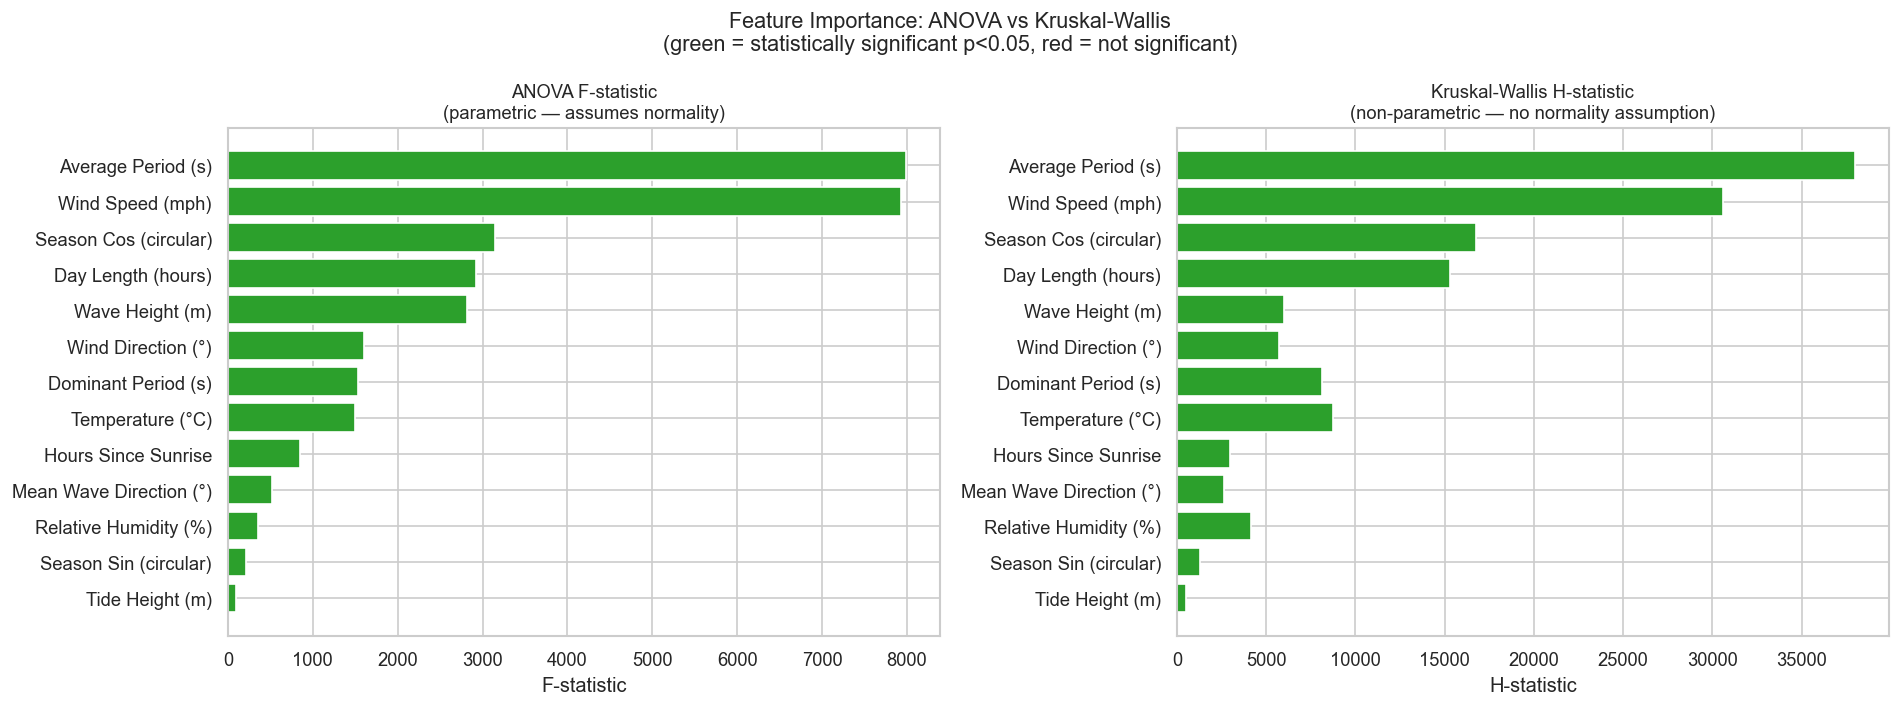

MOST important (ANOVA F-statistic):
                label           F  p_anova            H  p_kruskal
   Average Period (s) 7984.258145      0.0 37991.421524        0.0
     Wind Speed (mph) 7930.920003      0.0 30608.146720        0.0
Season Cos (circular) 3148.148148      0.0 16734.051238        0.0
   Day Length (hours) 2928.421912      0.0 15275.041925        0.0

LEAST important:
                label          F       p_anova           H     p_kruskal
Relative Humidity (%) 357.393082  0.000000e+00 4140.132478  0.000000e+00
Season Sin (circular) 217.321292 9.956409e-278 1310.423061 6.002146e-280
      Tide Height (m)  97.236962 1.274767e-122  515.223449 4.414916e-108


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
anova_colors   = ['#2ca02c' if s else '#d62728' for s in imp['sig_anova']]
kruskal_colors = ['#2ca02c' if s else '#d62728' for s in imp['sig_kruskal']]

axes[0].barh(imp['label'][::-1], imp['F'][::-1], color=anova_colors[::-1])
axes[0].set_title('ANOVA F-statistic\n(parametric — assumes normality)', fontsize=11)
axes[0].set_xlabel('F-statistic')

axes[1].barh(imp['label'][::-1], imp['H'][::-1], color=kruskal_colors[::-1])
axes[1].set_title('Kruskal-Wallis H-statistic\n(non-parametric — no normality assumption)', fontsize=11)
axes[1].set_xlabel('H-statistic')

plt.suptitle('Feature Importance: ANOVA vs Kruskal-Wallis\n(green = statistically significant p<0.05, red = not significant)', fontsize=13)
plt.tight_layout()
plt.show()

print('MOST important (ANOVA F-statistic):')
print(imp.head(4)[['label','F','p_anova','H','p_kruskal']].to_string(index=False))
print('\nLEAST important:')
print(imp.tail(3)[['label','F','p_anova','H','p_kruskal']].to_string(index=False))

## 7. Correlation Heatmap

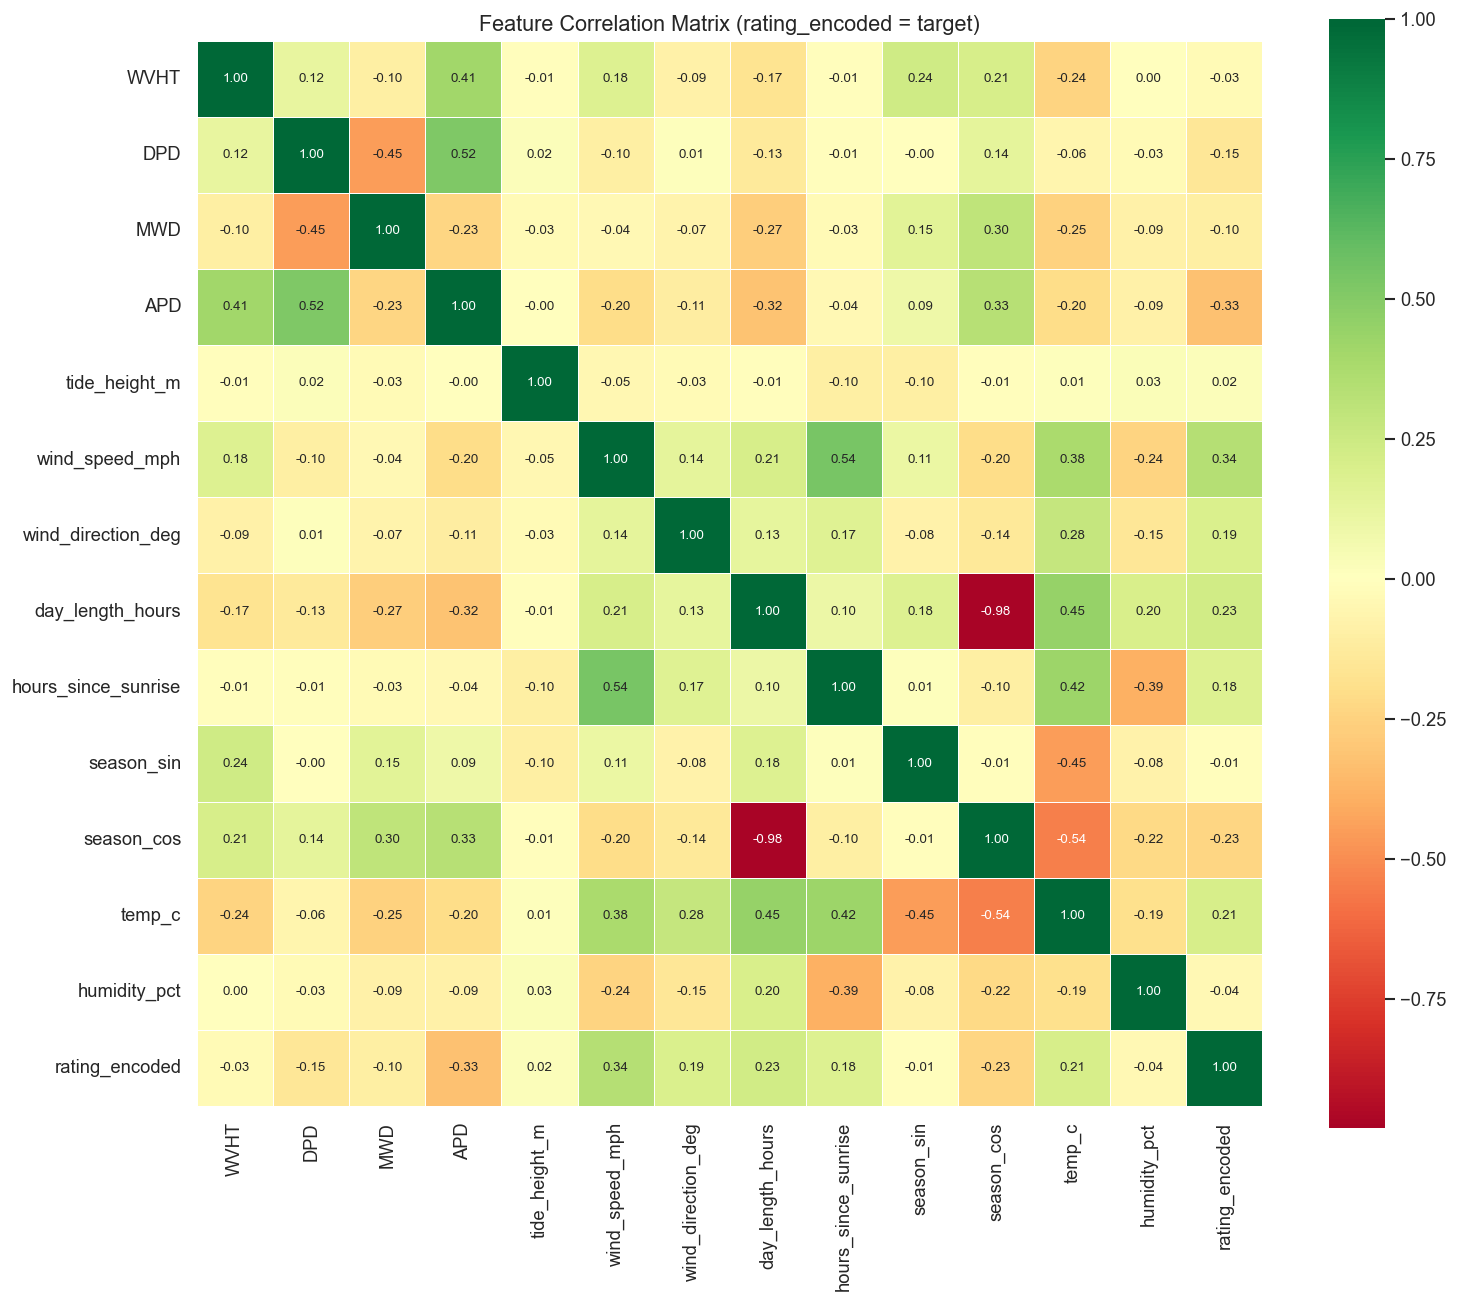

In [12]:
df['rating_encoded'] = LabelEncoder().fit_transform(df['rating_key'].fillna('POOR'))
corr = df[FEATURE_COLS + ['rating_encoded']].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix (rating_encoded = target)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Per-Break Analysis

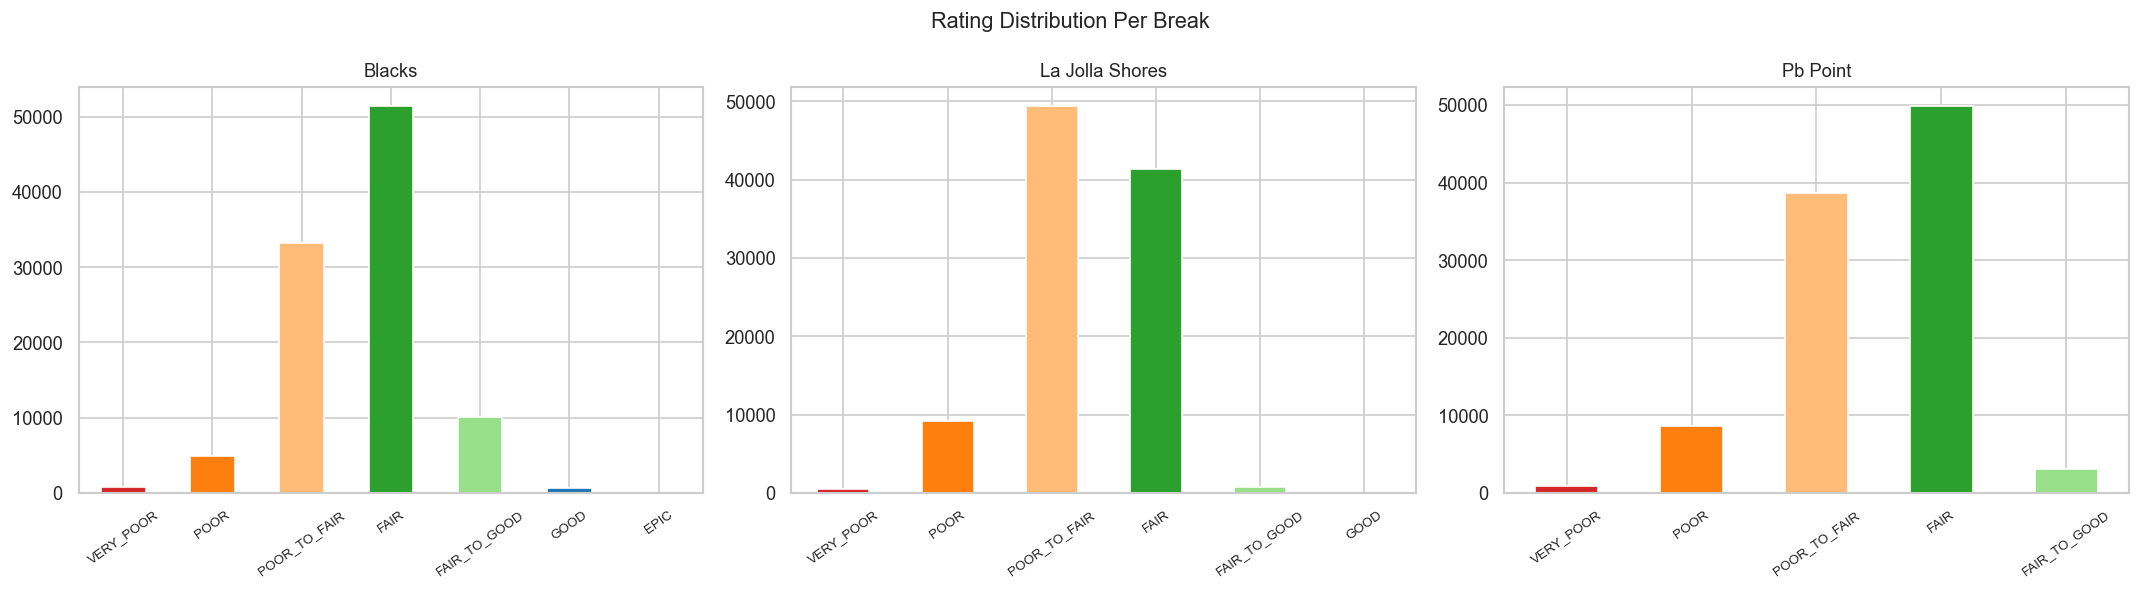

In [13]:
breaks = ['blacks','la_jolla_shores','pb_point']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, bid in zip(axes, breaks):
    counts = df[df['break_id']==bid]['rating_key'].value_counts().reindex(RATING_ORDER).dropna()
    counts.plot(kind='bar', ax=ax, color=PALETTE[:len(counts)], edgecolor='white')
    ax.set_title(bid.replace('_',' ').title(), fontsize=11)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.set_xlabel('')
plt.suptitle('Rating Distribution Per Break', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Summary

In [14]:
print('='*60)
print('SURFCAST SD — EDA SUMMARY')
print('='*60)
print(f'Rows:            {len(df):,}')
print(f'Features:        {len(FEATURE_COLS)}')
print(f'Class imbalance: {df["rating_key"].value_counts(normalize=True).max()*100:.0f}% in dominant class')
print()
print('MOST IMPORTANT (ANOVA F-statistic):')
for _, r in imp.head(4).iterrows():
    print(f'  {r["label"]:30s}  F={r["F"]:8.1f}  p_anova={r["p_anova"]:.2e}  H={r["H"]:8.1f}  p_kruskal={r["p_kruskal"]:.2e}')
print()
print('LEAST IMPORTANT:')
for _, r in imp.tail(3).iterrows():
    print(f'  {r["label"]:30s}  F={r["F"]:8.1f}  p_anova={r["p_anova"]:.2e}  H={r["H"]:8.1f}  p_kruskal={r["p_kruskal"]:.2e}')
print('='*60)

SURFCAST SD — EDA SUMMARY
Rows:            303,375
Features:        13
Class imbalance: 47% in dominant class

MOST IMPORTANT (ANOVA F-statistic):
  Average Period (s)              F=  7984.3  p_anova=0.00e+00  H= 37991.4  p_kruskal=0.00e+00
  Wind Speed (mph)                F=  7930.9  p_anova=0.00e+00  H= 30608.1  p_kruskal=0.00e+00
  Season Cos (circular)           F=  3148.1  p_anova=0.00e+00  H= 16734.1  p_kruskal=0.00e+00
  Day Length (hours)              F=  2928.4  p_anova=0.00e+00  H= 15275.0  p_kruskal=0.00e+00

LEAST IMPORTANT:
  Relative Humidity (%)           F=   357.4  p_anova=0.00e+00  H=  4140.1  p_kruskal=0.00e+00
  Season Sin (circular)           F=   217.3  p_anova=9.96e-278  H=  1310.4  p_kruskal=6.00e-280
  Tide Height (m)                 F=    97.2  p_anova=1.27e-122  H=   515.2  p_kruskal=4.41e-108
